In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update(plt.rcParamsDefault)

def get_scaled_fontsizes(fig_width, fig_height, base_figsize=(6, 4), base_fontsizes=None):
    if base_fontsizes is None:
        base_fontsizes = {
            'label': 16,
            'title': 16,
            'legend': 14,
            'xtick': 14,
            'ytick': 14
        }
    width_scale = fig_width / base_figsize[0]
    height_scale = fig_height / base_figsize[1]
    scale = (width_scale + height_scale) / 2.0

    return {k: v * scale for k, v in base_fontsizes.items()}

def apply_figure_style(fig_width=7.2, fig_height=5):
    fonts = get_scaled_fontsizes(fig_width, fig_height)
    plt.rcParams.update({
        #'text.usetex': True,
        'font.family': 'STIXGeneral',
        'mathtext.fontset': 'cm',
        'figure.figsize': (fig_width, fig_height),
        'axes.labelsize': fonts['label'],
        'axes.titlesize': fonts['title'],
        'legend.fontsize': fonts['legend'],
        'xtick.labelsize': fonts['xtick'],
        'ytick.labelsize': fonts['ytick'],
        'axes.linewidth': 1,
    })

apply_figure_style(6, 4)

In [ ]:
def cohens_d (val, dist):
    """ Compute Cohen's d effect size between a value and a distribution. """
    mean_dist = np.mean(dist)
    std_dist = np.std(dist, ddof=1)
    d = (val - mean_dist) / std_dist
    return d


/local/lauraelina.uronen/ipykernel_1346402/3414156871.py:1: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  from mpl_toolkits.axes_grid.inset_locator import inset_axes
/local/lauraelina.uronen/ipykernel_1346402/3414156871.py:28: RuntimeWarning: invalid value encountered in scalar divide
  prob = np.sum(percentile90 < y_rel_90) / len(percentile90)
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


0
10000
10000


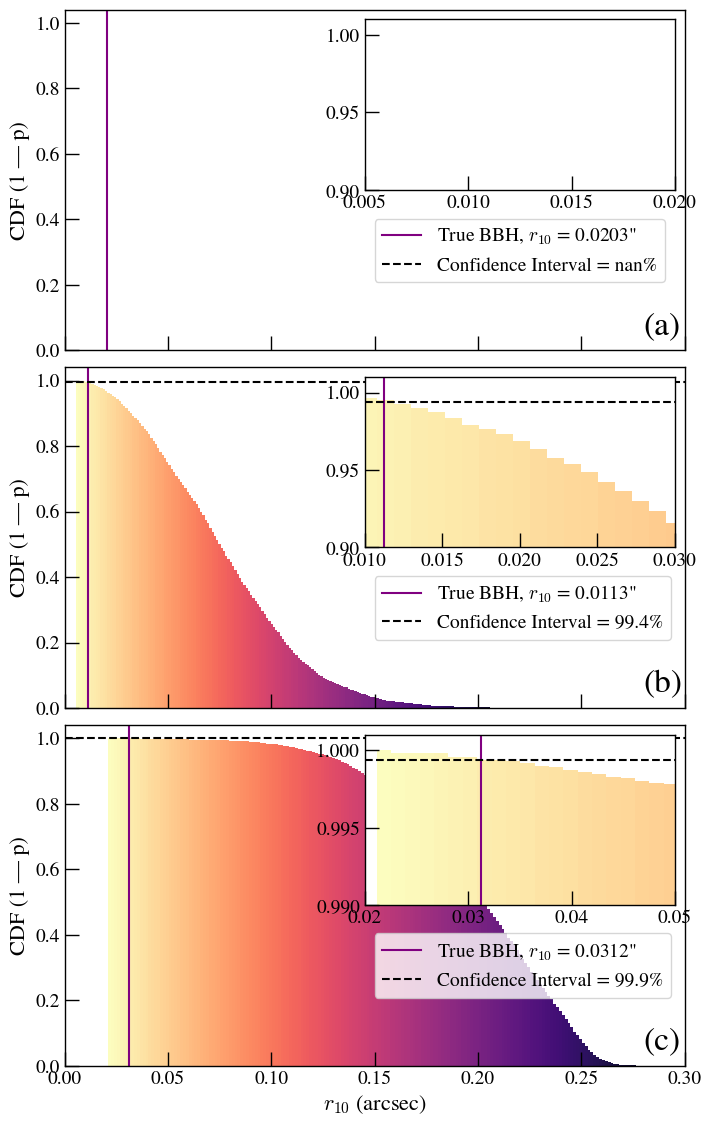

In [ ]:
from mpl_toolkits.axes_grid.inset_locator import inset_axes

fig, axes = plt.subplots(3, 1, figsize=(8,12))
cm = plt.cm.get_cmap('magma_r')

ax = axes[0]
real_event_path = '/home/lauraelina.uronen/GClocalization/small_system/Outdir_lens_reconstruction/true_position.json'
import json 
with open(real_event_path) as f:
    real_event = json.load(f)

y_rel_90 = real_event['90th_percentile']
percentile90 = []
n = 0 

for j in range(0,10):
    for i in range(0,100):
        title = f'small_system/batch_{j}/writefile_{i}.json'
        if os.path.exists(title):
            data = json.load(open(title))
            for key in data.keys():
                percentile90.append(data[key])
                n += 1

print(n)

percentile90 = np.array(percentile90).flatten()
prob = np.sum(percentile90 < y_rel_90) / len(percentile90)

n, bins, patches = ax.hist(percentile90, 200, color='green', density=True, cumulative=-1, range=(0.0, 0.11))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

ax.set_ylabel('CDF (1 — p)')
ax.axvline(y_rel_90, color='purple', linestyle='-', label=r'True BBH, $r_{10}$ = '+f'{y_rel_90:.4f}"')
ax.axhline(1-prob, linestyle='--', c='black', label=f'1 — FAP = {(1-prob)*100:.1f}%')
ax.set_xlim(0.0, 0.3)
ax.set_ylim(0,1.04)
ax.set_xticklabels([])
ax.tick_params(axis='both', direction='in', length=10, width=1)
ax.text(0.28, 0.05, '(a)', fontsize=24)
ax.legend(loc=(0.5,0.2))

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

# Create inset axes
axins = inset_axes(ax, width="50%", height="50%", loc=1)
n, bins, patches = axins.hist(percentile90, cumulative=-1, density=True, bins=200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c)) 

axins.axvline(y_rel_90, color='purple', linestyle='-', label='True BBH')
axins.axhline(1-prob, linestyle='--', c='black')
axins.set_xlim(0.005, 0.02)
axins.set_ylim(0.9,1.01)
axins.tick_params(axis='both', direction='in', length=10, width=1)

ax = axes[1]

real_event_path = '/home/lauraelina.uronen/GClocalization/average_system/Outdir_lens_reconstruction/true_position.json'
with open(real_event_path) as f:
    real_event = json.load(f)

y_rel_90 = real_event['90th_percentile']
percentile90 = []
n = 0 

for j in range(0,10):
    for i in range(0,100):
        title = f'average_system/batch_{j}/writefile_{i}.json'
        if os.path.exists(title):
            data = json.load(open(title))
            for key in data.keys():
                percentile90.append(data[key])
                n += 1

print(n)

percentile90 = np.array(percentile90).flatten()
prob = np.sum(percentile90 < y_rel_90) / len(percentile90)

n, bins, patches = ax.hist(percentile90, 200, color='green', density=True, cumulative=-1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

ax.set_ylabel('CDF (1 — p)')
ax.axvline(y_rel_90, color='purple', linestyle='-', label=r'True BBH, $r_{10}$ = '+f'{y_rel_90:.4f}"')
ax.axhline(1-prob, linestyle='--', c='black', label=f'1 — FAP = {(1-prob)*100:.1f}%')
ax.set_xlim(0.0, 0.3)
ax.set_ylim(0,1.04)
ax.set_xticklabels([])
ax.tick_params(axis='both', direction='in', length=10, width=1)
ax.text(0.28, 0.05, '(b)', fontsize=24)
ax.legend(loc=(0.5,0.2))

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

# Create inset axes
axins = inset_axes(ax, width="50%", height="50%", loc=1)
n, bins, patches = axins.hist(percentile90, cumulative=-1, density=True, bins=200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c)) 

axins.axvline(y_rel_90, color='purple', linestyle='-', label='True BBH')
axins.axhline(1-prob, linestyle='--', c='black')
axins.set_xlim(0.01, 0.03)
axins.set_ylim(0.9,1.01)
axins.tick_params(axis='both', direction='in', length=10, width=1)

ax = axes[2]
real_event_path = '/home/lauraelina.uronen/GClocalization/best_system/Outdir_lens_reconstruction/true_position.json'
with open(real_event_path) as f:
    real_event = json.load(f)

y_rel_90 = real_event['90th_percentile']
percentile90 = []
n = 0 

for j in range(0,10):
    for i in range(0,100):
        title = f'best_system/batch_{j}/writefile_{i}.json'
        if os.path.exists(title):
            data = json.load(open(title))
            for key in data.keys():
                percentile90.append(data[key])
                n += 1

print(n)           
percentile90 = np.array(percentile90).flatten()
prob = np.sum(percentile90 < y_rel_90) / len(percentile90)

n, bins, patches = ax.hist(percentile90, 200, color='green', density=True, cumulative=-1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

ax.set_xlabel(r'$r_{10}$ (arcsec)')
ax.set_ylabel('CDF (1 — p)')
ax.axvline(y_rel_90, color='purple', linestyle='-', label=r'True BBH, $r_{10}$ = '+f'{y_rel_90:.4f}"')
ax.axhline(1-prob, linestyle='--', c='black', label=f'1 — FAP = {(1-prob)*100:.1f}%')
ax.set_xlim(0.0, 0.3)
ax.set_ylim(0,1.04)
ax.tick_params(axis='both', direction='in', length=10, width=1)
ax.legend(loc=(0.5,0.2))
ax.text(0.28, 0.05, '(c)', fontsize=24)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

# Create inset axes
axins = inset_axes(ax, width="50%", height="50%", loc=1)
n, bins, patches = axins.hist(percentile90, cumulative=-1, density=True, bins=200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c)) 

axins.axvline(y_rel_90, color='purple', linestyle='-', label='True BBH')
axins.axhline(1-prob, linestyle='--', c='black')
axins.tick_params(axis='both', direction='in', length=10, width=1)
axins.set_xlim(0.02, 0.05)
axins.set_ylim(0.99,1.001)

plt.subplots_adjust(left=None, bottom=0, right=None, top=None, wspace=None, hspace=0.05)
plt.savefig('triple_neg_cdf.pdf', bbox_inches='tight', dpi=500)

10000


10000


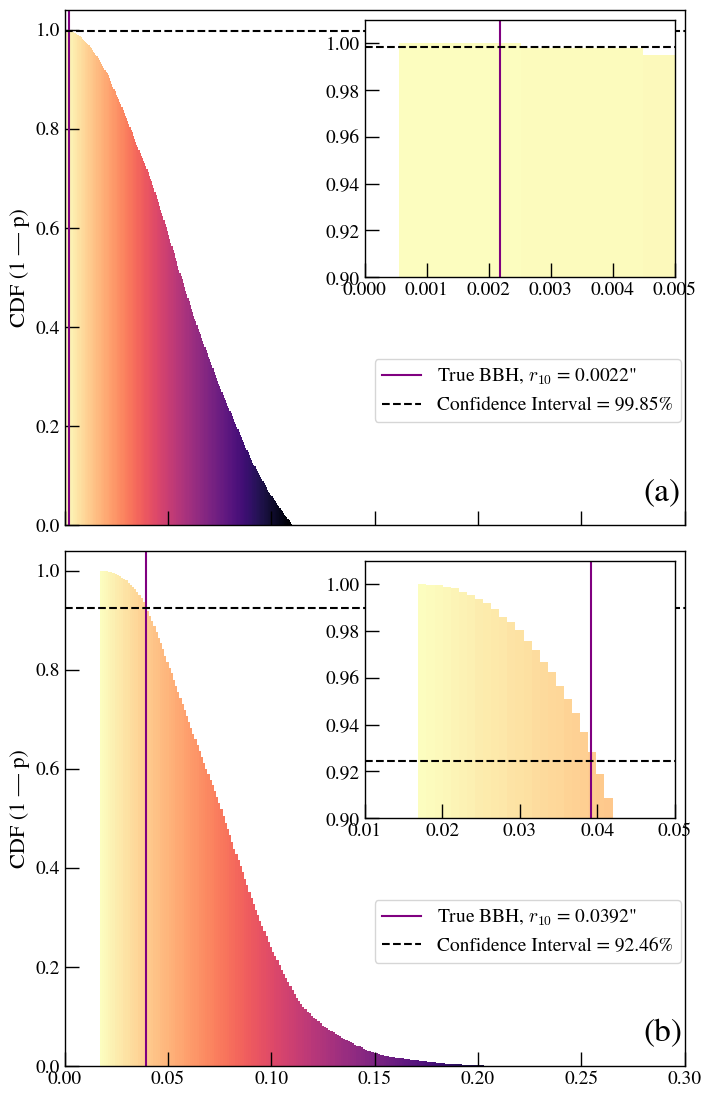

In [ ]:
from mpl_toolkits.axes_grid.inset_locator import inset_axes

fig, axes = plt.subplots(2, 1, figsize=(8,12))
cm = plt.cm.get_cmap('magma_r')

ax = axes[0]
real_event_path = '/home/lauraelina.uronen/GClocalization/average_system_rrel/Outdir_lens_reconstruction/true_position.json'
import json 
with open(real_event_path) as f:
    real_event = json.load(f)

y_rel_90 = real_event['90th_percentile']
percentile90 = []
n = 0 

for j in range(0,10):
    for i in range(0,100):
        title = f'average_system_rrel/batch_{j}/writefile_{i}.json'
        if os.path.exists(title):
            data = json.load(open(title))
            for key in data.keys():
                percentile90.append(data[key])
                n += 1

print(n)

percentile90 = np.array(percentile90).flatten()
prob = np.sum(percentile90 < y_rel_90) / len(percentile90)

n, bins, patches = ax.hist(percentile90, 200, color='green', density=True, cumulative=-1, range=(0.0, 0.11))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

ax.set_ylabel('CDF (1 — p)')
ax.axvline(y_rel_90, color='purple', linestyle='-', label=r'True BBH, $r_{10}$ = '+f'{y_rel_90:.4f}"')
ax.axhline(1-prob, linestyle='--', c='black', label=f'1 — FAP = {(1-prob)*100:.2f}%')
ax.set_xlim(0.0, 0.3)
ax.set_ylim(0,1.04)
ax.set_xticklabels([])
ax.tick_params(axis='both', direction='in', length=10, width=1)
ax.text(0.28, 0.05, '(a)', fontsize=24)
ax.legend(loc=(0.5,0.2))

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

# Create inset axes
axins = inset_axes(ax, width="50%", height="50%", loc=1)
n, bins, patches = axins.hist(percentile90, cumulative=-1, density=True, bins=200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c)) 

axins.axvline(y_rel_90, color='purple', linestyle='-', label='True BBH')
axins.axhline(1-prob, linestyle='--', c='black')
axins.set_xlim(0.0, 0.005)
axins.set_ylim(0.9,1.01)
axins.tick_params(axis='both', direction='in', length=10, width=1)

ax = axes[1]

real_event_path = '/home/lauraelina.uronen/GClocalization/average_system_unc/Outdir_lens_reconstruction/true_position.json'
with open(real_event_path) as f:
    real_event = json.load(f)

y_rel_90 = real_event['90th_percentile']
percentile90 = []
n = 0 

for j in range(0,10):
    for i in range(0,100):
        title = f'average_system_unc/batch_{j}/writefile_{i}.json'
        if os.path.exists(title):
            data = json.load(open(title))
            for key in data.keys():
                percentile90.append(data[key])
                n += 1

print(n)

percentile90 = np.array(percentile90).flatten()
prob = np.sum(percentile90 < y_rel_90) / len(percentile90)

n, bins, patches = ax.hist(percentile90, 200, color='green', density=True, cumulative=-1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

ax.set_ylabel('CDF (1 — p)')
ax.axvline(y_rel_90, color='purple', linestyle='-', label=r'True BBH, $r_{10}$ = '+f'{y_rel_90:.4f}"')
ax.axhline(1-prob, linestyle='--', c='black', label=f'1 — FAP = {(1-prob)*100:.2f}%')
ax.set_xlim(0.0, 0.3)
ax.set_ylim(0,1.04)
ax.tick_params(axis='both', direction='in', length=10, width=1)
ax.text(0.28, 0.05, '(b)', fontsize=24)
ax.legend(loc=(0.5,0.2))

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

# Create inset axes
axins = inset_axes(ax, width="50%", height="50%", loc=1)
n, bins, patches = axins.hist(percentile90, cumulative=-1, density=True, bins=200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c)) 

axins.axvline(y_rel_90, color='purple', linestyle='-', label='True BBH')
axins.axhline(1-prob, linestyle='--', c='black')
axins.set_xlim(0.01, 0.05)
axins.set_ylim(0.9,1.01)
axins.tick_params(axis='both', direction='in', length=10, width=1)

plt.subplots_adjust(left=None, bottom=0, right=None, top=None, wspace=None, hspace=0.05)
plt.savefig('test_neg_cdf.pdf', bbox_inches='tight', dpi=500)